In [ ]:
import os
import sys

In [ ]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xraylib
from omegaconf import OmegaConf

from src.model.atom.atom import Atom
from src.model.crystal.crystal import Crystal

In [40]:
cfg = OmegaConf.load("../config/alpha-Fe.yaml")

In [41]:
cr = Crystal(
    cfg.a,
    cfg.b,
    cfg.c,
    cfg.alpha,
    cfg.beta,
    cfg.gamma,
    cfg.space_group,
    [Atom(*atom) for atom in cfg.atoms],
)

Hall number: 529
Schoenflies: Oh^9
International: I 4/m -3 2/m


In [42]:
theta_deg = np.linspace(0, 90, 500)
theta_rad = np.radians(theta_deg)

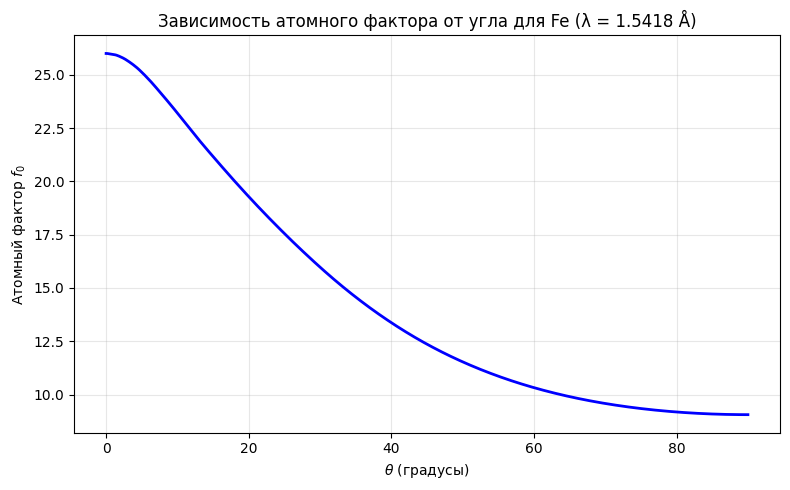

In [ ]:
s_vals = np.sin(theta_rad) / cfg.wavelength
atomic_number = xraylib.SymbolToAtomicNumber(cr.atoms[0].element)
f0_vals = []
for s in s_vals:
    if s > 0:
        f0 = xraylib.FF_Rayl(atomic_number, s)
    else:
        f0 = atomic_number
    f0_vals.append(f0)

plt.figure(figsize=(8, 5))
plt.plot(theta_deg, f0_vals, "b-", linewidth=2)
plt.xlabel(r"$\theta$ (градусы)")
plt.ylabel(r"Атомный фактор $f_0$")
plt.title(
    f"Зависимость атомного фактора от угла для {cr.atoms[0].element} (λ = {cfg.wavelength} Å)"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("3.png")